### 第12章 图像轮廓
#### 12.1 查找和绘制轮廓
- 查找图像轮廓函数为`contours, hierarchy = cv2.findContours(image, mode, method)`， 其中
    - contours 返回的轮廓
        - 类型属性 type(contours) -> <class 'list'>
        - 图像中的轮廓个数 len(contours) 
        - 每个轮廓的点数 len(contours[i]) -> 第i个轮廓的长度（点的个数）
        - 获取每个轮廓内点的形状属性 contours[i].shape
        - 轮廓内的点 contours[i] -> 轮廓内每个点的坐标
    - hierarchy 图像的轮廓层次
        - 外部的轮廓称为父轮廓，内部的轮廓称为子轮廓，每个轮廓 contours[i]有4个元素表示层次关系，没有对应关系时值为-1
            - Next 后一个轮廓的索引编号
            - Previous 前一个轮廓的索引编号
            - First_Child 第一个子轮廓的索引编号
            - Parent 父轮廓的索引编号
    - image 输入图像，8位单通道图像所有非零值被处理为1，零值保持不变，即灰度图会被自动处理为二值图像
    - mode 轮廓检索模式
        - `cv2.RETR_EXTERNAL`：只检测外轮廓
        - `cv2.RETR_LIST`：对检测到的轮廓不建立等级关系
        - `cv2.RETR_CCOMP`：检索所有轮廓并将它们组织成两级层次结构。上层为外边界，下层为内边界
        - `cv2.RETR_TREE`：建立等级树结构的轮廓，仅有两层轮廓时，与`cv2.RETR_CCOMP`层次结构一致。当有多层结构时，`cv2.RETR_CCOMP`仍然只能得到两个层次结构；而`cv2.RETR_TREE`会得到多个层次的结构
    - method 轮廓的近似方法
        - `cv2.CHAIN_APPROX_NONE`：存储所有的轮廓点，相邻两个像素点的位置差不超过1
        - `cv2.CHAIN_APPROX_SIMPLE`：压缩水平方向、垂直方向、对角线方向的元素，只保留该方向的终点坐标
        - `cv2.CHAIN_APPROX_TC89_L1`：使用 teh-Chin1 chain 近似算法的一种风格
        - `cv2.CHAIN_APPROX_TC89_KCOS`：使用 teh-Chin1 chain 近似算法的一种风格
- 注意事项：
    - 源图像必须是灰度二值图。通常情况下，要预先对图像进行阈值分割或者边缘检测，得到合适的二值图像
    - 在 OpenCV 中都是从黑色背景中查找白色图像。因此对象必须是白色的，背景必须是黑色的

- `image = cv2.drawContours(image, contours, contourIdx, color[, thickness[, lineType[, hierarchy[, maxLevel[, offset]]]]])`是绘制图像轮廓函数，也可以写成没有返回值的形式。无论是否具有返回值，该函数都在原始图像上绘制轮廓。其中
    - image 待绘制轮廓的图像，注意函数执行会在image上直接绘制轮廓，需要预先复制副本图像传递给函数使用
    - contours 需要绘制的轮廓，与`cv2.findContours()`的输出相同
    - contoursIdx 需要绘制轮廓的索引，如果该值为负数，表示绘制全部轮廓
    - color 绘制的颜色，用 BGR 表示
    - thickness 表示绘制轮廓时所用画笔粗细的可选值，`-1`表示实心轮廓
    - lineType 表示绘制轮廓时所用线型的可选值
    - hierarchy 对应`cv2.findContours()`输出的层次信息
    - maxLevel 控制所绘制轮廓层次的深度，应为非负数，表示绘制最高层及以下数量层级的轮廓
    - offset 偏移参数，使轮廓偏移到不同位置展示出来
    
- 使用函数`cv2.findContours`和函数`cv2.draawContours`可以将图像的前景区域提取出来

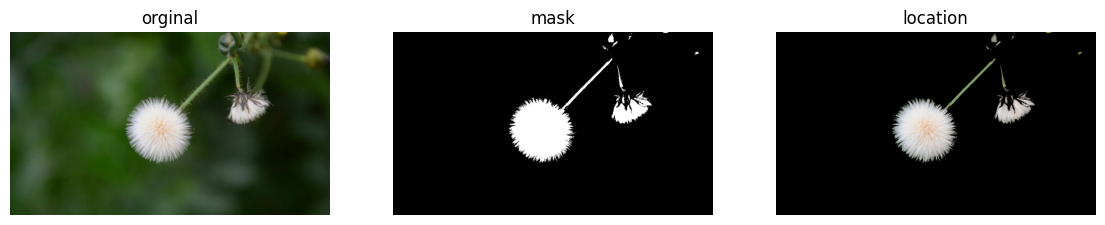

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
import numpy as np
o = cv2.imread('loc1.jpg')
gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY) 

# cv2.findContours会把所有非零值视为前景，所以需要对图像进行二值化处理，才能找到轮廓，否则几乎整幅图像全都是轮廓 
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
mask = np.zeros(o.shape, np.uint8)
mask = cv2.drawContours(mask, contours, -1, (255,255,255), -1) 
loc = cv2.bitwise_and(o, mask)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
loc = cv2.cvtColor(loc, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 4))
plt.subplot(131)
plt.imshow(o)
plt.title("orginal")
plt.axis("off")
plt.subplot(132)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")
plt.subplot(133)
plt.imshow(loc)
plt.title("location")
plt.axis("off")
plt.show()

#### 12.2 轮廓特征
- 获取轮廓矩函数`retval = cv2.moments(array[, binaryImage])`， 其中
    - array 可以是点集或者灰度图像。如果是点集，则函数将整个点集视为一条轮廓
    - binaryImage 当array为图像时，若该值为True，则array内所有非零值均视为1
    - 返回值retval是矩特征，主要包括空间矩、中心矩和归一化中心矩：
        - 零阶矩`m00`表示一个轮廓的面积
        - 中心矩通过减去均值得到平移不变性，因而能够比较不同位置的两个对象是否一致
        - 归一化中心矩通过除以物体尺寸得到缩放不变性

- 计算轮廓的面积`retval = cv2.contourArea(contour [, oriented])`， 其中
    - 返回值retval是面积值
    - contour 是轮廓
    - oriented 为True时，返回值的正/负号表示轮廓是顺时针/逆时针；默认值为False，表示返回值是绝对值

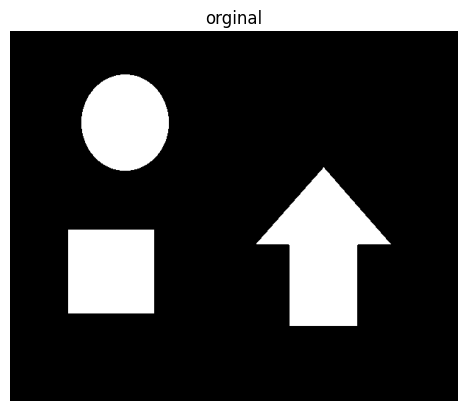

contours[0] area: 13108.0
contours[1] area: 19535.0
contours[2] area: 12058.0


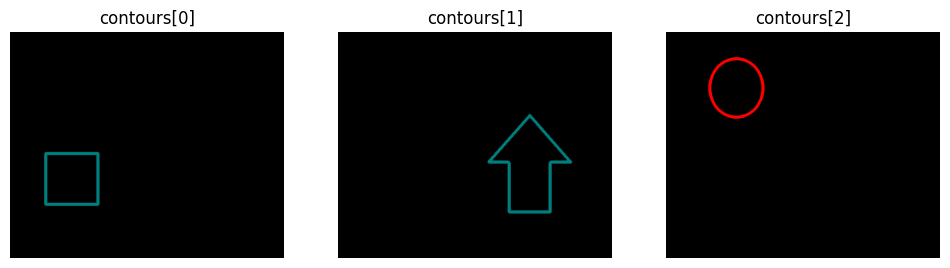

In [17]:
# 筛选出大于指定面积的轮廓
import cv2
import numpy as np

o = cv2.imread('contours.bmp')  
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
plt.imshow(o)
plt.title("orginal")
plt.axis("off")
plt.show()

gray = cv2.cvtColor(o,cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  

n = len(contours)
contoursImg = []
plt.figure(figsize=(12,4))
for i in range(n):
    temp = np.zeros(o.shape, np.uint8)
    contoursImg.append(temp)
    print("contours[" + str(i) + "] area: " + str(cv2.contourArea(contours[i])))
    if cv2.contourArea(contours[i]) > 13000:
        # 大于指定面积的用青色表示
        contoursImg[i] = cv2.drawContours(contoursImg[i], contours, i, (127,127,0), 5)
    else:
        # 小于指定面积的用红色表示
        contoursImg[i] = cv2.drawContours(contoursImg[i], contours, i, (0,0,255), 5)
    contoursImg[i] = cv2.cvtColor(contoursImg[i], cv2.COLOR_BGR2RGB)
    plt.subplot(1, n, i+1)
    plt.imshow(contoursImg[i])
    plt.title("contours[" + str(i)+"]")
    plt.axis("off")
plt.show()



- 计算轮廓的长度`retval = cv2.arcLength(curve, closed)`， 其中
    - 返回值retval是轮廓的周长值
    - contour 是轮廓
    - oriented 为True时，表示轮廓是封闭的

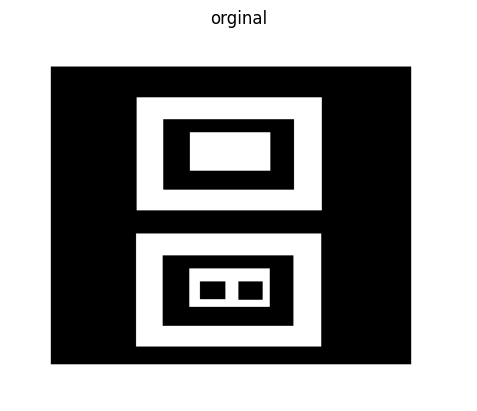

第0个轮廓的长度为: 145
第1个轮廓的长度为: 147
第2个轮廓的长度为: 398
第3个轮廓的长度为: 681
第4个轮廓的长度为: 1004
第5个轮廓的长度为: 398
第6个轮廓的长度为: 681
第7个轮廓的长度为: 1004
第8个轮廓的长度为: 2225
第9个轮廓的长度为: 2794
全部轮廓的总长度为：9480
全部轮廓的平均长度为：948


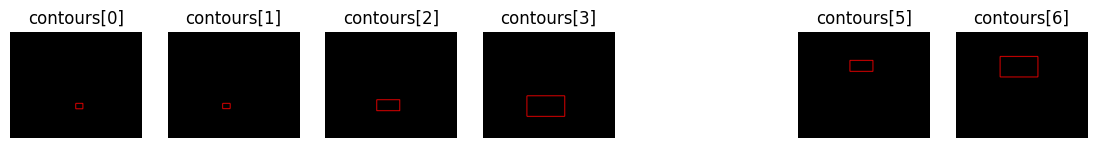

In [ ]:
# 筛选出长度小于平均值的轮廓
import cv2
import numpy as np
o = cv2.imread('contoursLength.bmp')  
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
plt.imshow(o)
plt.title("orginal")
plt.axis("off")
plt.show()

# 获取轮廓
gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
# 计算各个轮廓的长度和平均值
n = len(contours)   
cntLen = []                 # 存储各个轮廓的长度
for i in range(n):
    cntLen.append(cv2.arcLength(contours[i], True))
    print("第"+str(i)+"个轮廓的长度为: %d"%cntLen[i])
Sum = np.sum(cntLen)  # 轮廓长度和
Avr = Sum/n     # 轮廓长度平均值
print("全部轮廓的总长度为：%d" %Sum)
print("全部轮廓的平均长度为：%d" %Avr)

contoursImg = []
plt.figure(figsize=(20,4))
for i in range(n):
    temp = np.zeros(o.shape,np.uint8)
    contoursImg.append(temp)
    contoursImg[i] = cv2.drawContours(contoursImg[i], contours, i, (0,0,255), 3)
    if cv2.arcLength(contours[i],True) < Avr: # 显示长度小于平均值的轮廓  
        contoursImg[i] = cv2.cvtColor(contoursImg[i], cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(contoursImg[i])
        plt.title("contours[" + str(i)+"]")
        plt.axis("off")  
plt.show()

#### 12.3 Hu 矩
- 归一化中心矩的线性组合在图像旋转、缩放、平移等操作后仍能保持不变性，称为 Hu 矩
- Hu 矩函数`hu = cv2.HuMoments(m)`， 其中
    - 返回值hu，表示返回的Hu矩值
    - m 是由`cv2.moments()`计算得到的矩特征值

- 可以通过Hu矩判断两个对象的一致性，使用函数`retval = cv2.mathcShapes(contour1, contour2, method, parameter)`， 其中
    - 返回值是retval
    - contour1/countour2 分别是进行比较的两个轮廓或灰度图像
    - method 是比较两个对象Hu矩的方法，取值分别为`cv2.CONTOURS_MATCH_I1`, `cv2.CONTOURS_MATCH_I2`和`cv2.CONTOURS_MATCH_I3`
    - parameter 应用于method的扩展参数，设置为0

o1.shape= (425, 514, 3)
o2.shape= (42, 51, 3)
o3.shape= (425, 514, 3)
相同图像的matchShape = 0.0
相似图像的matchShape = 0.10720296440067095
不相似图像的matchShape = 0.5338506830800509


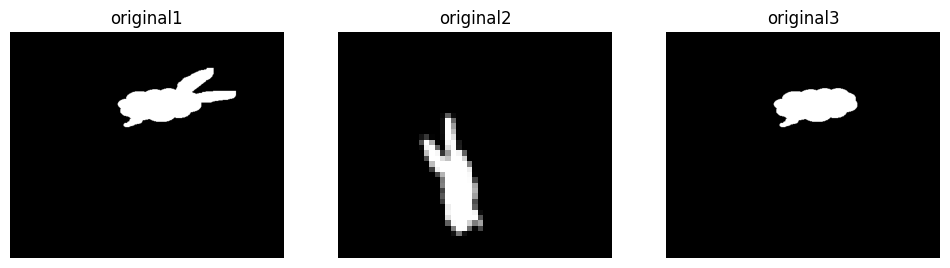

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
o1 = cv2.imread('cs1.bmp')
o2 = cv2.imread('cs2.bmp')
o3 = cv2.imread('cc.bmp')  
gray1 = cv2.cvtColor(o1, cv2.COLOR_BGR2GRAY) 
gray2 = cv2.cvtColor(o2, cv2.COLOR_BGR2GRAY) 
gray3 = cv2.cvtColor(o3, cv2.COLOR_BGR2GRAY) 

# 使用轮廓最为参数
ret, binary1 = cv2.threshold(gray1, 127, 255, cv2.THRESH_BINARY) 
ret, binary2 = cv2.threshold(gray2, 127, 255, cv2.THRESH_BINARY) 
ret, binary3 = cv2.threshold(gray3, 127, 255, cv2.THRESH_BINARY) 
contours1, hierarchy = cv2.findContours(binary1, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
contours2, hierarchy = cv2.findContours(binary2, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
contours3, hierarchy = cv2.findContours(binary3, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
cnt1 = contours1[0]
cnt2 = contours2[0]
cnt3 = contours3[0]
ret0 = cv2.matchShapes(cnt1, cnt1, 1, 0.0)
ret1 = cv2.matchShapes(cnt1, cnt2, 1, 0.0)
ret2 = cv2.matchShapes(cnt1, cnt3, 1, 0.0)

# 使用灰度图像作为参数，比较结果的值有所不同
# ret0 = cv2.matchShapes(gray1,gray1,1,0.0)
# ret1 = cv2.matchShapes(gray1,gray2,1,0.0)
# ret2 = cv2.matchShapes(gray1,gray3,1,0.0)

print("o1.shape=",o1.shape)
print("o2.shape=",o2.shape)
print("o3.shape=",o3.shape)
print("相同图像的matchShape =", ret0)
print("相似图像的matchShape =", ret1)
print("不相似图像的matchShape =", ret2)

o1 = cv2.cvtColor(o1, cv2.COLOR_BGR2RGB)
o2 = cv2.cvtColor(o2, cv2.COLOR_BGR2RGB)
o3 = cv2.cvtColor(o3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(o1)
plt.title("original1")
plt.axis("off")

plt.subplot(132)
plt.imshow(o2)
plt.title("original2")
plt.axis("off")

plt.subplot(133)
plt.imshow(o3)
plt.title("original3")
plt.axis("off")
plt.show()

#### 12.4 轮廓拟合
- 在计算轮廓时，往往并不需要实际的轮廓，而是需要一个近似轮廓的多边形
- 函数`retval = cv2.boundingRect(array)`能够绘制轮廓的矩形边界，其中
    - retval 表示返回的矩形边界的左上角顶点坐标，以及矩形边界的宽度和高度
    - array 是灰度图像或轮廓
- 该函数也可以写成4个返回值的形式
    - `x, y, w, h = cv2.boundingRect(array)`，其中x和y表示矩形边界左上角的坐标，w和h分别表示x和y方向的长度

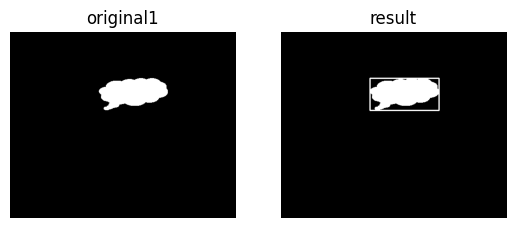

x =  202
y =  107
w =  157
h =  73


In [ ]:
import cv2
import numpy as np
o = cv2.imread('cc.bmp')  
plt.subplot(121)
plt.imshow(o)
plt.title("original1")
plt.axis("off")

gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE) 
# 构造矩形边界
x, y, w, h = cv2.boundingRect(contours[0])
brcnt = np.array([[[x, y]], [[x+w, y]], [[x+w, y+h]], [[x, y+h]]])

# cv2.drawContours(o, [brcnt], -1, (255, 255,255), 2)   # 利用cv2.drawContours函数绘制矩形边界
cv2.rectangle(o, (x, y), (x+w, y+h), (255, 255, 255), 2)    # 利用cv2.rectangle函数绘制矩形边界

plt.subplot(122)
plt.imshow(o)
plt.title("result")
plt.axis("off")
plt.show()

print("x = ", x)
print("y = ", y)
print("w = ", w)
print("h = ", h)

- 函数`retval = cv2.minAreaRect(points)`能够绘制轮廓的最小包围矩形，其中
    - retval 表示返回的矩形特征信息 `(最小外接矩形中心(x,y), (宽度, 高度), 旋转角度)`
    - points 是轮廓
- 注意返回值retval需要格式转换才能用于`cv2.drawContours()`，转换函数为`points = cv2.boxPoints(box)`，其中
    - points 是能够用于`cv2.drawContours()`参数的轮廓
    - box 是`retval = cv2.minAreaRect(points)`的返回值类型的结果

返回值rect:
 ((280.3700256347656, 138.58999633789062), (154.99778747558594, 63.781028747558594), -8.130102157592773)

转换后的points:
 [[208.16005  181.11998 ]
 [199.14003  117.979996]
 [352.58002   96.06001 ]
 [361.60004  159.2     ]]


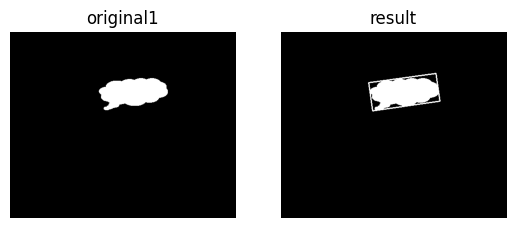

In [ ]:
import cv2
import numpy as np
o = cv2.imread('cc.bmp')  
plt.subplot(121)
plt.imshow(o)
plt.title("original1")
plt.axis("off")

gray = cv2.cvtColor(o, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
rect = cv2.minAreaRect(contours[0])
print("返回值rect:\n",rect)             # 返回值rect是一个包含三个元素的元组，分别是矩形中心坐标、宽高和旋转角度
points = cv2.boxPoints(rect)
print("\n转换后的points:\n",points)    # cv2.boxPoints函数将返回的rect转换为4个顶点坐标

points = np.intp(points)                # 新版Numpy取整函数 np.intp 代替旧版 np.int0
image = cv2.drawContours(o, [points], 0, (255,255,255), 2)
plt.subplot(122)
plt.imshow(o)
plt.title("result")
plt.axis("off")
plt.show()

- 函数`center, radius = cv2.minEnclosingCirlce(points)`能够构造对象的最小包围圆形，其中
    - center 是最小包围圆形的中心；radius 是最小包围圆形的半径
    - points 是轮廓
- 函数`retval = cv2.fitEllipse(points)`用来构造最优拟合椭圆，也可以写成`(x,y), (MA,ma), angle = cv2.fitEllipse(points)`，其中
    - retval 是RotateRect类型，是拟合椭圆的外接矩形，包含矩形的质心、宽、高、旋转角度等，对应椭圆的中心点、轴长、旋转角度，可以在绘制椭圆函数`cv2.ellipse()`内使用。
        - (x, y)：椭圆的中心点
        - (MA, ma)：椭圆水平方向轴和垂直方向轴的长度
        - angle：椭圆的旋转角度
    - points 是轮廓
- 函数`retval, trangle = cv2.minEnclosingTrangle(points)`用来构造最小外包三角形，其中
    - retval 是最小外包三角形的面积；trangle 是最小外包三角形的三个顶点
    - points 是轮廓

rectangle = ((280, 137), 78)
ellipse = ((276.2112731933594, 139.6067352294922), (63.01350021362305, 166.72308349609375), 82.60102844238281)
area = 12904.00390625
trgl: [[[441.41028 107.     ]]

 [[193.25641 107.     ]]

 [[222.58974 211.     ]]]


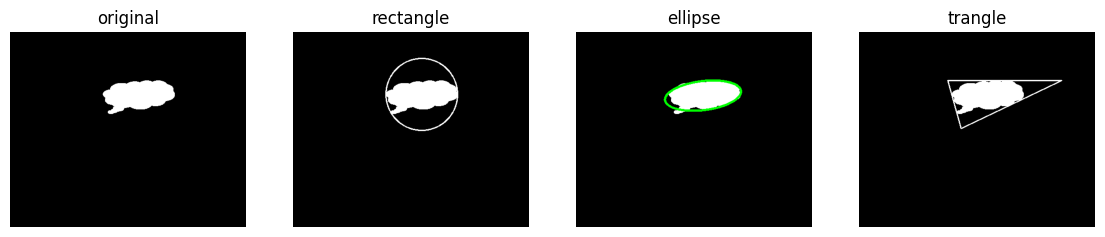

In [9]:
import matplotlib.pyplot as plt
import cv2
o1 = cv2.imread('cc.bmp')  
plt.figure(figsize=(14, 4))
plt.subplot(141)
plt.imshow(o1)   
plt.title("original")
plt.axis("off")

gray = cv2.cvtColor(o1, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
(x,y), radius = cv2.minEnclosingCircle(contours[0])
center = (int(x), int(y))
radius = int(radius)
print("rectangle =", (center, radius))
cv2.circle(o1, center, radius, (255,255,255), 2)
plt.subplot(142)
plt.imshow(o1)   
plt.title("rectangle")
plt.axis("off")

o2 = cv2.imread('cc.bmp')  
gray = cv2.cvtColor(o2, cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
# cv2.imshow("original",o)
ellipse = cv2.fitEllipse(contours[0])
print("ellipse =", ellipse)
cv2.ellipse(o2, ellipse, (0,255,0), 3)
plt.subplot(143)
plt.imshow(o2)   
plt.title("ellipse")
plt.axis("off")

o3 = cv2.imread('cc.bmp')  
gray = cv2.cvtColor(o3,cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
area, trgl = cv2.minEnclosingTriangle(contours[0])
print("area =", area)
print("trgl:", trgl)
for i in range(0, 3):
    pt1 = (int(trgl[i][0][0]), int(trgl[i][0][1]))
    pt2 = (int(trgl[(i + 1) % 3][0][0]), int(trgl[(i + 1) % 3][0][1]))
    cv2.line(o3, pt1, pt2, (255,255,255), 2)
plt.subplot(144)
plt.imshow(o3)   
plt.title("trangle")
plt.axis("off")
plt.show()

- 函数`approxCurve = cv2.approxPolyDP(curve, epsilon, closed)`采用 Douglas-Peucker 算法，构造指定精度的逼近多边形，其中
    - approxCurve 是逼近多边形的点集
    - curve 是轮廓
    - epsilon 是精度，即原始轮廓的边界与逼近多边形边界之间的最大距离，通常设置为多边形总长度的百分比
    - closed 为Ture时，逼近多边形是封闭的；反之，逼近多边形是不封闭的。

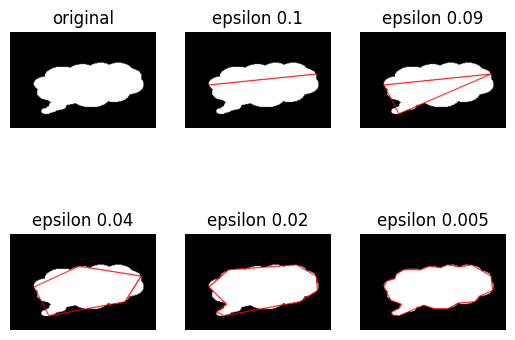

In [ ]:
import matplotlib.pyplot as plt
import cv2
#----------------读取并显示原始图像-------------------------------
o = cv2.imread('ccbig.bmp') 
plt.subplot(231)
plt.imshow(o)   
plt.title("original")
plt.axis("off")
#----------------获取轮廓-------------------------------
gray = cv2.cvtColor(o,cv2.COLOR_BGR2GRAY)  
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  
contours, hierarchy = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)  
#---------------- epsilon = 0.1*周长 -------------------------------
adp = o.copy()
epsilon = 0.1 * cv2.arcLength(contours[0],True)
approx = cv2.approxPolyDP(contours[0],epsilon,True)
adp = cv2.drawContours(adp, [approx], 0, (255,0,0), 2)
plt.subplot(232)
plt.imshow(adp)   
plt.title("epsilon 0.1")
plt.axis("off")
#---------------- epsilon = 0.09*周长 -------------------------------
adp = o.copy()
epsilon = 0.09 * cv2.arcLength(contours[0],True)
approx = cv2.approxPolyDP(contours[0],epsilon,True)
adp = cv2.drawContours(adp, [approx], 0, (255,0,0), 2)
plt.subplot(233)
plt.imshow(adp)   
plt.title("epsilon 0.09")
plt.axis("off")
#---------------- epsilon = 0.04*周长 -------------------------------
adp = o.copy()
epsilon = 0.04  *cv2.arcLength(contours[0],True)
approx = cv2.approxPolyDP(contours[0],epsilon,True)
adp = cv2.drawContours(adp, [approx], 0, (255,0,0), 2)
plt.subplot(234)
plt.imshow(adp)   
plt.title("epsilon 0.04")
plt.axis("off")
#----------------epsilon = 0.02*周长-------------------------------
adp = o.copy()
epsilon = 0.02 * cv2.arcLength(contours[0],True)
approx = cv2.approxPolyDP(contours[0],epsilon,True)
adp = cv2.drawContours(adp, [approx], 0, (255,0,0), 2)
plt.subplot(235)
plt.imshow(adp)   
plt.title("epsilon 0.02")
plt.axis("off")
#----------------epsilon = 0.005*周长-------------------------------
adp = o.copy()
epsilon = 0.005 * cv2.arcLength(contours[0],True)
approx = cv2.approxPolyDP(contours[0],epsilon,True)
adp = cv2.drawContours(adp, [approx], 0, (255,0,0), 2)
plt.subplot(236)
plt.imshow(adp)   
plt.title("epsilon 0.005")
plt.axis("off")
plt.show()